<h1 style="text-align:center;">Deep Reinforcement Learning for Online Optimal Execution Strategies</h1>

Source : [Paper](https://arxiv.org/pdf/2410.13493)

Source code: [github](https://github.com/ImperialCollegeLondon/deep_rl_liquidation)

## Sumary :

* [**1.Environment**](#0)
    * [1.1. Kernel](#0_1)
    * [1.2. Martingale](#0_2)
    * [1.3. Space](#0_3)
    * [1.4. State](#0_4)
    * [1.5. Environment](#0_5)

* [**2.Noise**](#1)
    * [2.1. Ornstein-Uhlenbeck](#1_1)

* [**3.Agents**](#2)
    * [3.1. Agents](#2_1)
    * [3.2. Optimal Agents](#2_2)
    * [3.3. Deep DPG Agents](#2_3)

* [**4.Architecture**](#3)
    * [4.1. Deep DPG architectures](#3_1)

* [**5.Experiment**](#4)
    * [5.1. Experiment utils](#4_1)
    * [5.2. Experiment](#4_2)

* [**6.Run**](#4)

In [34]:
from abc import ABC, abstractmethod
import torch
import numpy as np
import copy
import torch.nn as nn
import torch.optim as optim
import gymnasium as gym
from gymnasium.spaces import Dict
import itertools
import pickle
import matplotlib.pyplot as plt
import matplotlib
import json
import argparse
import random

<a id='0'></a>
# 1. Environment 

### 1.1 Kernel



**Kernels** $G : \mathbb{R}_+ \to \mathbb{R}_+$ :


| Class | $G(x)$ | Markovian |
|---|---|---|
| `ExponentialKernel` | $\lambda \, e^{-\rho x}$ | Markovian (récursion : $I_{t+1} = e^{-\rho} \, I_t + \lambda \, x_{t+1}$) |
| `PowerLawKernel` | $\lambda \, (1+x)^{-\rho}$ | Non markovian |
| `LinearResilienceKernel` | $\lambda \, (1-\rho x)^+$ | Finite-memory (semi-Markov) |


**Parameters** : $\lambda > 0$ (scale), $\rho > 0$ (decay). Each can be a **constant** or a **schedule** $({\lambda_k})_{k \geq 1}$, $({\rho_k})_{k \geq 1}$ updated across episodes via `update()` $\Rightarrow$ online setting.

In [35]:
class Kernel(ABC):

    def __init__(self, init_decay: float, init_scale: float, name=None):
        self.name = name

        self.init_decay = (
            init_decay
            if hasattr(init_decay, "__iter__")
            else itertools.repeat(init_decay)
        )
        self.init_scale = (
            init_scale
            if hasattr(init_scale, "__iter__")
            else itertools.repeat(init_scale)
        )

        # set kernel parameters
        self.reset_parameter()

        # keep track of history
        self.reset_history()

    @abstractmethod
    def __call__(self, x):
        pass

    def reset_parameter(self):
        # copy the parameters over which to iterate
        self.iter_decay = copy.deepcopy(self.init_decay)
        self.iter_scale = copy.deepcopy(self.init_scale)

        # iterate on first value of parameters
        self.current_scale = next(self.iter_scale)
        self.current_decay = next(self.iter_decay)

    def reset_history(self):
        self.scale_history = []
        self.decay_history = []
        self.scale_history.append(self.current_scale)
        self.decay_history.append(self.current_decay)

    def update(self):
        # update parameters
        self.current_scale = next(self.iter_scale)
        self.current_decay = next(self.iter_decay)

        # keep track to retrace history
        self.scale_history.append(self.current_scale)
        self.decay_history.append(self.current_decay)


class ExponentialKernel(Kernel):

    def __init__(self, init_decay: float, init_scale: float):
        super().__init__(
            init_decay=init_decay, init_scale=init_scale, name="Exponential kernel"
        )

    def __call__(self, x):
        return float(self.current_scale * np.exp(-x * self.current_decay))


class PowerLawKernel(Kernel):

    def __init__(self, init_decay: float, init_scale: float):
        super().__init__(
            init_decay=init_decay, init_scale=init_scale, name="Power Law kernel"
        )

    def __call__(self, x):
        return float(self.current_scale * np.power(1 + x, -self.current_decay))


class LinearResilienceKernel(Kernel):

    def __init__(self, init_decay: float, init_scale: float):
        super().__init__(
            init_decay=init_decay,
            init_scale=init_scale,
            name="Linear Resilience kernel",
        )

    def __call__(self, x):
        resilience = 1 - self.current_decay * x
        if resilience > 0:
            return float(self.current_scale * resilience)
        else:
            return float(0.0)

### 1.2 Martingale

**Unaffected price** $S^0$ — two models implemented as Python iterators (`__next__`):

| Class | Dynamics |
|---|---|
| `BrownianMotion` | $S^0_{t+1} = S^0_t + \sigma \sqrt{\tau} \, \varepsilon_{t+1}$ |
| `GeometricBrownianMotion` | $S^0_{t+1} = S^0_t \exp\!\left(-\tfrac{1}{2}\sigma^2 \tau + \sigma\sqrt{\tau}\,\varepsilon_{t+1}\right)$ |

where $\varepsilon_{t+1} \overset{\text{iid}}{\sim} \mathcal{N}(0,1)$, $\sigma > 0$ is the volatility, $\tau > 0$ the step size.

Both are **martingales** : $\mathbb{E}[S^0_{t+1} \mid \mathcal{F}_t] = S^0_t$.

In [36]:
class Martingale(ABC):

    def __init__(
        self,
        volatility: float,
        initialization: float,
        step_size: int = 1,
        seed: int = None,
    ):
        self.initialization = initialization
        self.price = initialization
        self.volatility = volatility
        self.rng = np.random.default_rng(seed)
        self.step_size = step_size

    def __iter__(self):
        return self

    @abstractmethod
    def __next__(self):
        pass

    def reset(self):
        self.price = copy.deepcopy(self.initialization)


class BrownianMotion(Martingale):

    def __next__(self):
        self.price += (
            self.volatility * np.sqrt(self.step_size) * self.rng.normal(0, 1, size=1)
        )
        return float(self.price)


class GeometricBrownianMotion(Martingale):

    def __next__(self):
        self.price *= np.exp(
            -0.5 * (self.volatility**2) * self.step_size
            + self.volatility * np.sqrt(self.step_size) * self.rng.normal(0, 1, size=1)
        )
        return float(self.price)

### 1.3 Space 

**Action space** $\mathcal{A}_t$ — quantity to trade at time $t$ :

$$\mathcal{A}_t = [-x_t,\ 0]$$

Bounds are **updated dynamically** after each trade ($\text{low} \leftarrow -x_t$) to enforce $x_{t+1} \leq x_t$ (no over-selling), then reset at the start of each episode.

**Observation space** $\mathcal{S}$ :

| Component | Bounds |
|---|---|
| $x_t$ (inventory) | $[0,\ X_0]$ |
| $S_t$ (price) | $[0,\ 100 \cdot S_0]$ |
| $t$ (time) | $[0,\ T]$ |
| $I_t$ (impact) | $[-100 \cdot S_0,\ 0]$ |

In [37]:
class ActionSpace(gym.spaces.Box):

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.init_low = copy.deepcopy(self.low)
        self.init_high = copy.deepcopy(self.high)

    def update(self, low=None, high=None):
        if low:
            self.low = low
        if high:
            self.high = high

    def reset(self):
        self.low = copy.deepcopy(self.init_low)
        self.high = copy.deepcopy(self.init_high)


class ObservationSpace:

    def __init__(
        self, initial_inventory: float, initial_price: float, time_horizon: int
    ):
        self.initial_inventory = initial_inventory
        self.initial_price = initial_price
        self.time_horizon = time_horizon

    def __call__(self):
        return Dict(
            {
                "inventory": gym.spaces.Box(low=0, high=self.initial_inventory),
                "price": gym.spaces.Box(low=0, high=self.initial_price * 100),
                "time": gym.spaces.Box(low=0, high=self.time_horizon),
                "impact": gym.spaces.Box(low=-self.initial_price * 100, high=0),
            }
        )

### 1.4 State

The state is a `dict` with fields :

$$s_t = \big(\underbrace{x_t}_{\text{inventory}},\ \underbrace{t}_{\text{time}},\ \underbrace{S_t}_{\text{price}},\ \underbrace{I_t}_{\text{impact}},\ \underbrace{(x_0,\ldots,x_t)}_{\text{past\_actions}}\big)$$

The **observation** returned to the agent is a subset of $s_t$ defined by `inputs` :

$$o_t = \{s_t[k],\ k \in \texttt{inputs}\} \subseteq s_t$$

Two terminal conditions :

$$\text{done} \iff t = T+1 \quad \text{or} \quad x_t = 0$$
$$\text{terminal} \iff t = T \quad \text{(forced full liquidation at next step)}$$

In [38]:
class State(dict):

    def __init__(
        self,
        init: dict,
        inputs: list,
        terminal_time: int,
        terminal_inventory: float,
        dtype,
    ):
        for k, v in init.items():
            super().__setitem__(k, v)
        self._init = init
        self._inputs = inputs
        self._terminal_time = terminal_time
        self._terminal_inventory = terminal_inventory
        self.dtype = dtype

    def reset(self):
        self.clear()
        self.update(self._init)

    def get_observation(self):
        observation = {obs: self[obs] for obs in self._inputs}
        return observation

    def get_current_price(self):
        return self["price"]

    def is_done(self):
        return (self["time"] == self._terminal_time + 1) or (
            self["inventory"] == self._terminal_inventory
        )

    def is_terminal(self):
        return self["time"] == self._terminal_time

### 1.5 Environment

**Transition** — at each step $t$, given action $x_{t+1} \leq 0$ (sell order) :

$$x_{t+1} \leftarrow x_t + x_{t+1} \quad \text{(clipped to 0 if } < \varepsilon\text{)}$$

$$t \leftarrow t + 1$$

$$I_{t+1} = \sum_{j \leq t+1} G(t+1 - j)\, x_j$$

$$S_{t+1} = S^0_{t+1} + I_{t+1}$$

**Reward** — based on the **jump price** $S_{t+} = S_t + x_{t+1} \cdot G(0)$ :

$$r_t = -\frac{S_{t+}^2 - S_t^2}{2\,G(0)} = -\frac{\big(S_t + x_{t+1} G(0)\big)^2 - S_t^2}{2\,G(0)}$$

$$= -S_t\, x_{t+1} - \frac{G(0)}{2}\,x_{t+1}^2$$

which corresponds to the **execution cost** of trading $x_{t+1}$ shares at the price $S_t$ with instantaneous impact $G(0)$.

In [39]:
class Environment(gym.Env):
    def __init__(
        self,
        martingale: Martingale,
        kernel: Kernel,
        state: State,
        observation_space: ObservationSpace,
        action_space: ActionSpace,
        tolerance: float,
    ):
        self.martingale = martingale
        self.kernel = kernel
        self.state = state
        self.observation_space = observation_space
        self.action_space = action_space
        self.tolerance = tolerance
        self.termination_time = int(self.observation_space["time"].high[0] + 1)
        self.actions_history = []

    def reset(self):
        self.martingale.reset()
        self.state.reset()
        self.action_space.reset()
        self.actions_history = []
        return (self.state, {})

    def save_action(self, action):
        # We cache time at which the action was performed
        # and what value for the action was chosen
        time = self.state["time"]
        self.actions_history.append((time, action))

    def transition_function(self, action):
        self.save_action(action)
        # Implement logic for transitioning from current state to next state based on action
        next_state = {}
        next_state["inventory"] = self.state["inventory"] + action
        next_state["inventory"] = (
            0
            if (next_state["inventory"] - 0) < self.tolerance
            else next_state["inventory"]
        )
        next_state["time"] = self.state["time"] + 1
        next_state["impact"] = sum(
            [
                self.kernel(next_state["time"] - pair[0]) * pair[1]
                for pair in self.actions_history
            ]
        )
        unaffected_price = next(self.martingale)
        next_state["price"] = unaffected_price + next_state["impact"]

        next_state["past_actions"] = [0] * int(self.termination_time)
        next_state["past_actions"][0 : len(self.actions_history)] = [
            action[1] for action in self.actions_history
        ]
        return next_state

    def get_reward(self, action):
        # We compute the jump price S_{i+} = S_{i} + \xi_{t_{n}}*G(0)  used in the penalty computation
        jump_price = self.state["price"] + action * self.kernel(0)
        penalty = pow(jump_price, 2) - pow(self.state["price"], 2)
        penalty /= 2 * self.kernel(0)
        return -penalty

    def step(self, action):
        # Perform action and move to next state
        next_state = self.transition_function(action)
        # Update the action space
        self.action_space.update(low=-next_state["inventory"])
        # Calculate reward
        reward = self.get_reward(action)
        # Update state
        self.state.update(next_state)
        # Check for terminal condition
        done = self.state.is_done()
        # Observe state
        observation = self.state.get_observation()
        return (
            observation,
            float(reward),
            bool(done),
        )

<a id='1'></a>

# 2. Noise

### 2.1. Ornstein-Uhlenbeck

Exploration noise for the actor, following the SDE :

$$d\eta_t = \theta(\mu - \eta_t)\,dt + \sigma\, dW_t$$

Discretised as :

$$\eta_{t+1} = \eta_t + \theta(\mu - \eta_t) + \sigma\,\varepsilon_{t+1}, \quad \varepsilon_{t+1} \sim \mathcal{N}(0,1)$$

| Parameter | Role | Default |
|---|---|---|
| $\mu$ | mean reversion level | $0$ |
| $\theta$ | mean reversion speed | $0.15$ |
| $\sigma$ | noise amplitude | $1$ |


In [40]:
# Ornstein-Uhlenbeck noise process
class OrnsteinUhlenbeckNoise:
    def __init__(self, size, mu=0, theta=0.15, sigma=1, device=torch.device("cpu")):
        self.size = size
        self.mu = mu
        self.theta = theta
        self.sigma = sigma
        self.device = device
        self.reset()

    def reset(self):
        # Initialize the noise state using PyTorch
        self.state = torch.ones(self.size) * self.mu

        # Move the tensor to the selected device
        self.state = self.state.to(self.device)

    def sample(self):

        # Get random gaussian noise
        noise = torch.randn(self.size)
        noise = noise.to(self.device)

        # Update the noise state using the Ornstein-Uhlenbeck process
        dx = self.theta * (self.mu - self.state) + self.sigma * noise
        self.state += dx

        return self.state

<a id='2'></a>

# 3. Agents

### 3.1 Agents

Abstract base class — any agent must implement :

$$\pi : \mathcal{S} \to \mathcal{A}, \quad s_t \mapsto x_{t+1} = \pi(s_t)$$

In [41]:
class Agent(ABC):
    """Abstract class representing an agent."""

    def __init__(self, name=None):
        """Initializes the agent with a name (optional for subclasses).

        Args:
        name: (Optional) The name of the agent.
        """
        self.name = name

    @abstractmethod
    def act(self, state):
        """Abstract method representing the agent's action.
        Subclasses must implement this method.

        Args:
            state (torch.tensor): Current state.
        """
        pass

### 3.2 Optimal Agents

Closed-form solution to the liquidation problem (see Section 1.1). The optimal strategy minimises the expected execution cost :

$$\min_{\mathbf{x}} \; \mathbf{x}^\top \mathbf{M} \mathbf{x} \quad \text{s.t.} \quad \mathbf{1}^\top \mathbf{x} = X_0$$

where $\mathbf{M} \in \mathbb{R}^{(N+1)\times(N+1)}$ is the **kernel matrix** :

$$M_{ij} = G(|i-j|), \quad i,j \in \{0,\ldots,N\}$$

The unique solution is :

$$
\boxed{
\mathbf{x}^* = \frac{X_0}{\mathbf{1}^\top \mathbf{M}^{-1} \mathbf{1}}\, \mathbf{M}^{-1}\mathbf{1}
}
$$

At time $t$, the agent executes $\pi(s_t) = x^*_t$.

In [42]:
class OptimalAgent(Agent):
    """An agent that computes and executes the optimal strategy for a given environment."""

    def __init__(self, env: gym.Env):
        """
        Args:
            env (gym.Env): The environment to interact with.
        """

        # Call the parent class constructor
        super().__init__("Optimal agent")

        # Initialize agent with environment object
        self.env = env
        self.termination_time = int(self.env.observation_space["time"].high[0])

    def act(self, state: np.array):
        """Returns the optimal action given the current state.

        Args:
            state (np.array): Current state.

        Returns:
            float: The optimal action.
        """

        action = self.get_optimal_strategy()[state["time"]]

        return action

    def get_optimal_strategy(self):
        """
        Computes the optimal strategy for the given environment.

        Returns:
            np.ndarray: The optimal strategy.
        """
        M = np.matrix(
            [
                [
                    self.env.kernel(abs(i - j))
                    for i in range(0, self.termination_time + 1)
                ]
                for j in range(0, self.termination_time + 1)
            ]
        )
        inverse_M = np.linalg.inv(M)
        strategy = self.env.state._init["inventory"]
        all_ones = np.ones(self.termination_time + 1)
        strategy /= np.matmul(np.matmul(all_ones, inverse_M), all_ones)
        strategy = strategy * np.matmul(inverse_M, all_ones)
        return -np.ravel(strategy)

### 3.3 Deep DPG Agents

## 3.3 Deep DPG Agent

The `DeepDPGAgent` implements the **Deep Deterministic Policy Gradient (DDPG)** algorithm adapted for the optimal liquidation problem.

---

### Architecture

DDPG uses **4 neural networks**:

| Network | Role |
|---|---|
| `actor_policy_network` | Learns the policy π(s) → action |
| `actor_target_network` | Stable copy of actor for TD targets |
| `critic_policy_network` | Estimates Q(s, a) |
| `critic_target_network` | Stable copy of critic for TD targets |

Target networks are updated via **soft (Polyak) update**:
$$\theta_{\text{target}} \leftarrow (1 - \tau)\,\theta_{\text{target}} + \tau\,\theta_{\text{policy}}$$

---

#### `__init__`

Initializes all networks, optimizers, replay buffer, and hyperparameters.  
Both actor and critic have independent learning rates, optimizers, and loss functions.  
The replay buffer `memory` stores tuples `(state, action, reward, next_state, done)`.

---

#### `act(state)`

Selects an action given the current state:
- If **terminal step** (`t = T`): sells the entire remaining inventory at once (forced liquidation).
- Otherwise: the actor network outputs a value in `[0, 1]`, multiplied by `-inventory` to get a valid sell order.
- During **training**, with probability `ε`, adds **Ornstein-Uhlenbeck noise** for exploration (applied in the transformed space via `inv_transform` / `transform`).

$$a_t = -x_t \cdot \pi_\theta(s_t)$$

---

#### `optimize(states)`

Computes the **target Q-values** using the target networks (no gradient):
- For non-terminal states: actor target network proposes the best action, critic target network evaluates it.
- For terminal states: full liquidation action is used directly.

$$Q^*(s, a) = Q_{\phi_{\text{target}}}(s,\; -x \cdot \pi_{\theta_{\text{target}}}(s))$$

---

#### `replay()`

Core **learning step**, called at every environment step once the buffer is full:

1. **Sample** a random mini-batch from the replay buffer (FIFO or uniform).
2. **Compute TD target** for the critic:
$$y = r + \gamma \cdot Q^*(s', a') \cdot (1 - \text{done}) + \underbrace{S_0 \cdot a}_{\text{auxiliary term (optional)}}$$
The auxiliary term (from the paper) exploits the martingale structure of the price to stabilize training.
3. **Update critic**: minimize MSE between `Q_policy(s, a)` and `y`.
4. **Update actor**: maximize `Q_policy(s, π(s))` (gradient ascent via negative loss).
5. **Decay ε**: reduce exploration rate until `epsilon_min`.
6. **Soft update** both target networks with rates `τ_critic` and `τ_actor`.

---

#### `normalize_states(states)` / `normalize_actions(actions, inventories)`

All inputs to the networks are **normalized** before being fed in:

| Feature | Normalization |
|---|---|
| Inventory $x_t$ | $x_t / X_0$ |
| Time $t$ | $t / (T+1)$ |
| Past actions | $\text{actions} / X_0$ |
| Price $S_t$ (optional) | $(S_t - S_0) / X_0$ |

This ensures all inputs lie in a comparable range, which stabilizes neural network training.

---

#### `get_input_actor(states)` / `get_input_critic(states, actions)`

Build the input tensors for each network:
- **Actor** receives normalized states only.
- **Critic** receives normalized states **concatenated** with normalized actions: `[s_norm | a_norm]`.

In [43]:
class DeepDPGAgent(Agent):
    """Deep Deterministic Policy Gradient (DDPG) agent for Reinforcement Learning."""

    def __init__(
        self,
        env: gym.Env,
        critic_architecture: nn.Module,
        actor_architecture: nn.Module,
        noise: OrnsteinUhlenbeckNoise,
        tau_critic: float,
        tau_actor: float,
        epsilon: float,
        epsilon_min: float,
        epsilon_decay: float,
        weight_decay_critic: float,
        batch_size: int,
        cache_size: int,
        fifo_replay: bool,
        lr_critic_optimizer: float,
        lr_actor_optimizer: float,
        critic_optimizer: optim.Optimizer,
        actor_optimizer: optim.Optimizer,
        criterion_critic: nn.Module = nn.MSELoss(),
        criterion_actor: nn.Module = nn.MSELoss(),
        price_in_input: bool = False,
        gamma: float = 1,
        auxiliary_bellman_equation: bool = True,
        current_price_in_auxiliary: bool = False,
        tolerance: float = 1e-6,
        dtype: torch.dtype = torch.float32,
        device: torch.device = torch.device("cpu"),
    ):
        """
        Args:
            env (gym.Env):
                The environment to interact with.
            critic_architecture (nn.Module):
                The architecture of the critic network.
                This network should take (state, action) as input and output a
                predicted Q-value.
            actor_architecture (nn.Module):
                The architecture of the actor network.
                This network should take state as input and output an action.
            noise (OrnsteinUhlenbeckNoise):
                A Ornstein-Uhlenbeck noise process used for exploration during training.
            tau_critic (float):
                Target network update rate for critic.
            tau_actor (float):
                Target network update rate for actor
            epsilon (float):
                Exploration rate at the start of the experiment.
            epsilon_min (float):
                Minimum exploration rate.
            epsilon_decay (float):
                Exploration rate decay.
            weight_decay_critic (float):
                Weight decay parameter for critic optimizer.
            batch_size (int):
                Batch size for experience replay.
            cache_size (int):
                Experience replay buffer size.
            fifo_replay (bool):
                Memory replay buffer is a FIFO Queue
            device (torch.device):
                Device on which to perform torch computation
            lr_critic_optimizer (float):
                Learning rate for the critic optimizer.
            lr_actor_optimizer (float):
                Learning rate for the actor optimizer.
            critic_optimizer (optim.Optimizer):
                The optimizer class used to train the critic network.
            actor_optimizer (optim.Optimizer):
                The optimizer class used to train the actor network.
            criterion_critic (nn.Module, optional):
                Loss function for critic network.
                Defaults to nn.MSELoss().
            criterion_actor (nn.Module, optional):
                Loss function for actor network.
                Defaults to nn.MSELoss().
            gamma (float, optional):
                Discount factor.
                Defaults to 1.0.
            auxiliary_bellman_equation (bool, optional):
                Whether to use the auxiliary Bellman equation.
                Defaults to True.
            tolerance (float, optional):
                Tolerance level to declare liquidation.
                Defaults to 1e-6.
            dtype (torch.dtype, optional):
                Data type for tensors.
                Defaults to torch.float32.
        """

        # Call the parent class constructor
        super().__init__("Deep DPG Agent")

        # Save environment parameters
        self.env = env
        self.termination_time = self.env.observation_space["time"].high[0]
        self.tolerance = tolerance
        self.dtype = dtype
        self.device = device
        self.noise = noise

        # Define Hyperparameters
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.tau_critic = tau_critic
        self.tau_actor = tau_actor
        self.batch_size = batch_size
        self.cache_size = cache_size
        self.fifo_replay = fifo_replay
        self.auxiliary_bellman_equation = auxiliary_bellman_equation
        self.current_price_in_auxiliary = current_price_in_auxiliary
        self.price_in_input = price_in_input

        # Initialize critic network
        self.critic_policy_network = copy.deepcopy(critic_architecture)

        # Initialize critic target network
        self.critic_target_network = copy.deepcopy(critic_architecture)
        self.critic_target_network.load_state_dict(
            copy.deepcopy(self.critic_policy_network.state_dict())
        )

        # Set-up critic optimizer
        self.critic_optimizer = critic_optimizer(
            self.critic_policy_network.parameters(),
            lr=lr_critic_optimizer,
            weight_decay=weight_decay_critic,
        )
        self.criterion_critic = criterion_critic

        # Initialize actor policy network
        self.actor_policy_network = copy.deepcopy(actor_architecture)

        # Initialize actor policy and target networks
        self.actor_target_network = copy.deepcopy(actor_architecture)
        self.actor_target_network.load_state_dict(
            copy.deepcopy(self.actor_policy_network.state_dict())
        )

        # Set-up actor optimizer
        self.actor_optimizer = actor_optimizer(
            self.actor_policy_network.parameters(), lr=lr_actor_optimizer
        )
        self.criterion_actor = criterion_actor

        # initialize experience replay
        self.memory = []
        self.critic_loss = []
        self.actor_loss = []

        # set agent to training mode
        self.train()

    def eval(self):
        self.training = False

    def train(self):
        self.training = True

    def act(self, state):
        """Choose action using policy networks.

        Args:
            state (torch.tensor): Current state.

        Raises:
            ValueError: if action is NaN.
            ValueError: if action is positive (i.e., buy).

        Returns:
            torch.tensor: Choosen action at current state.
        """

        # Set policy networks to evaluation mode
        self.actor_policy_network.eval()

        # Liquidate everything if termination time is reached
        if self.env.state.is_terminal():
            best_action = -torch.tensor(
                [self.env.state["inventory"]], dtype=self.dtype, device=self.device
            )
        else:

            # Get action from actor network
            best_action = self.actor_policy_network(
                self.get_input_actor(
                    state.unsqueeze(0),
                )
            ).squeeze(0)

            # Add noise if required
            if self.training and np.random.random() < self.epsilon:
                noise = self.noise.sample()  # randomly sample noise
                best_action = self.actor_policy_network.transform(
                    (self.actor_policy_network.inv_transform(best_action) + noise)
                )

            # Multiply best action with current inventory
            best_action *= -self.env.state["inventory"]

            if torch.isnan(best_action):
                raise ValueError("best action is nan")

            if best_action > 0:
                raise ValueError("best action should be negative")

        # Set actor policy networks back to training mode
        self.actor_policy_network.train()

        return best_action.detach()

    def optimize(
        self,
        states: torch.tensor,
    ):
        """Value function under optimal policy given target networks.

        Args:
            states (torch.tensor): torch.tensor of states.

        Returns:
            torch.tensor: Q-value under optimal policy at each state.
        """

        # Set traget networks to evaluation mode
        self.actor_target_network.eval()
        self.critic_target_network.eval()

        # Create mask for non-terminal states
        mask = states[:, 1] < self.termination_time

        # Calculate optimal actions with actor network
        best_actions = -states[:, 0].view(-1, 1)  # inventory
        best_actions[mask] *= self.actor_target_network(self.get_input_actor(states))[
            mask
        ]  # multiply inventory by output of NN (in [0,1]) for non-terminal states

        # Calculate Q-values with critic network
        max_q_values = self.critic_target_network(
            self.get_input_critic(states, best_actions)
        )

        # Set target networks back to training mode
        self.actor_target_network.train()
        self.critic_target_network.train()

        return max_q_values.squeeze().detach()

    def replay(self):
        if len(self.memory) < self.cache_size:
            return

        if self.fifo_replay and len(self.memory) > self.cache_size:
            memory = self.memory[-self.cache_size :]
        else:
            memory = self.memory

        # Sample a batch of experience tuples from memory
        batch_index = np.random.choice(
            range(0, len(memory)),
            size=min(len(memory), self.batch_size),
            replace=False,
        ).astype(int)
        batch = [memory[i] for i in batch_index]
        (
            states,
            actions,
            rewards,
            next_states,
            dones,
        ) = zip(*batch)

        # Convert to tensors
        dones = torch.cat(dones).float()
        rewards = torch.cat(rewards)
        states = torch.stack(states, dim=0)
        actions = torch.stack(actions, dim=0)
        next_states = torch.stack(next_states, dim=0)

        # Calculate target Q-values
        with torch.no_grad():
            q_values_next_states = self.optimize(
                states=next_states,
            )
            target_q_values = rewards + self.gamma * q_values_next_states * (1 - dones)
            if self.current_price_in_auxiliary:
                target_q_values += (
                    self.env.state.get_current_price() * actions.squeeze(1)
                ) * self.auxiliary_bellman_equation
            else:
                target_q_values += (
                    self.env.state._init["price"] * actions.squeeze(1)
                ) * self.auxiliary_bellman_equation

        # Critic Loss
        q_values = self.critic_policy_network(self.get_input_critic(states, actions))
        critic_loss = self.criterion_critic(q_values.squeeze(), target_q_values).to(
            self.device
        )
        self.critic_loss.append(critic_loss.detach())

        # Critic backward pass
        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()

        # Actor Loss
        mask = states[:, 1] < self.termination_time
        actions_values = -states[:, 0].view(-1, 1)
        actions_values[mask] *= self.actor_policy_network(self.get_input_actor(states))[
            mask
        ]

        self.critic_policy_network.eval()
        actor_loss = (
            -self.critic_policy_network(self.get_input_critic(states, actions_values))
            .mean()
            .to(self.device)
        )
        self.critic_policy_network.train()

        self.actor_loss.append(actor_loss.detach())

        # Actor backward pass
        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()

        # Update epsilon
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

        # Update target critic network weights
        for t, p in zip(
            self.critic_target_network.parameters(),
            self.critic_policy_network.parameters(),
        ):
            t.data = (1 - self.tau_critic) * t.data + self.tau_critic * p.data

        # Update target actor network weights
        for t, p in zip(
            self.actor_target_network.parameters(),
            self.actor_policy_network.parameters(),
        ):
            t.data = (1 - self.tau_actor) * t.data + self.tau_actor * p.data

    def get_input_critic(self, states, actions):

        return torch.cat(
            (
                self.normalize_states(states),
                self.normalize_actions(actions, states[:, 0].unsqueeze(1)),
            ),
            dim=1,
        )

    def get_input_actor(self, states):

        return self.normalize_states(states)

    def normalize_states(self, states):

        normalized_states = copy.deepcopy(states)

        # Normalize first column: inventory_t / inventory_0
        normalized_states[:, 0] = (
            normalized_states[:, 0] / self.env.state._init["inventory"]
        )

        # Normalize second column:  t / T
        normalized_states[:, 1] = normalized_states[:, 1] / (
            self.env.state._terminal_time + 1
        )

        # Normalize third column: past actions
        normalized_states[:, 2:] = self.normalize_actions(
            -normalized_states[:, 2:],
            torch.ones_like(normalized_states[:, 2:]),
        )

        # If price in input, normalize fourth column: (price_t - price_0) / inventory_0
        if self.price_in_input:
            normalized_states[:, 3] -= self.env.state._init["price"]
            normalized_states[:, 3] /= self.env.state._init["inventory"]

        return normalized_states

    def normalize_actions(self, actions, inventories):

        return actions / self.env.state._init["inventory"]

<a id='3'></a>

# 4. Architecture

### 4.1 Deep DPG architectures

Both actor and critic are **Fully Connected Networks (FCN)** with the following structure:
```
Input (input_dim)
    → Linear + Activation          # first hidden layer
    → Linear + Activation  × (num_layers - 2)   # hidden layers
    → Linear                       # output layer
Output (output_dim)
```

---

### `FCN` — Critic Network

Generic FCN used as the critic $Q_\phi(\hat{\pi}(s), a)$. The **output layer has no activation** — the Q-value is unbounded real-valued.

| Parameter | Default | Role |
|---|---|---|
| `input_dim` | 4 | Size of concatenated `[state | action]` input |
| `feature_dim` | 20 | Width of each hidden layer |
| `num_layers` | 4 | Total depth (input + hidden + output) |
| `output_dim` | 1 | Scalar Q-value |
| `activation` | `ReLU` | Hidden layers activation |

---

### `ActorFCN` — Actor Network

Same architecture as `FCN` but the **output layer applies `transform` (sigmoid)** to constrain the output to $(0, 1)$, representing the fraction of remaining inventory to sell.

| Parameter | Default | Role |
|---|---|---|
| `activation` | `sigmoid` | Hidden layers activation |
| `transform` | `sigmoid` | Output activation: maps to $(0,1)$ |
| `inv_transform` | `logit` | Inverse of sigmoid, used in `act()` to inject OU noise in unconstrained space |

The final action is:
$$a_t = -X_t \cdot \underbrace{\sigma\!\left(\xi_\theta(\hat{\pi}(s_t))\right)}_{\in\,(0,1)}$$

During exploration, OU noise is added **before** re-applying sigmoid to preserve the $(0,1)$ constraint:
$$a_t^{\text{noisy}} = -X_t \cdot \sigma\!\Big(\underbrace{\text{logit}\big(\sigma(\xi_\theta(\hat{\pi}(s_t)))\big)}_{\text{inv\_transform}} + \varepsilon\Big)$$

In [44]:
class FCN(nn.Module):
    def __init__(
        self,
        input_dim=4,
        feature_dim=20,
        num_layers=4,
        output_dim=1,
        activation=torch.nn.ReLU(),
    ):
        super().__init__()

        # map u to y -- REVIEWED
        fcls = list()
        fcls.append(nn.Linear(input_dim, feature_dim, bias=True))
        for k in range(num_layers - 2):
            fcls.append(nn.Linear(feature_dim, feature_dim, bias=True))
        fcls.append(nn.Linear(feature_dim, output_dim, bias=True))
        self.fc = nn.ModuleList(fcls)

        self.activation = activation

    def forward(self, x):
        x = self.activation(self.fc[0](x))
        for linear in self.fc[1:-1]:
            x = self.activation(linear(x))
        x = self.fc[-1](x)
        return x


class ActorFCN(nn.Module):
    def __init__(
        self,
        input_dim=4,
        feature_dim=20,
        num_layers=4,
        output_dim=1,
        activation=torch.sigmoid,
        transform=torch.sigmoid,
        inv_transform=torch.special.logit,
    ):
        super().__init__()

        # map u to y -- REVIEWED
        fcls = list()
        fcls.append(nn.Linear(input_dim, feature_dim, bias=True))
        for k in range(num_layers - 2):
            fcls.append(nn.Linear(feature_dim, feature_dim, bias=True))
        fcls.append(nn.Linear(feature_dim, output_dim, bias=True))
        self.fc = nn.ModuleList(fcls)

        self.activation = activation
        self.transform = transform
        self.inv_transform = inv_transform

    def forward(self, x):
        x = self.activation(self.fc[0](x))
        for linear in self.fc[1:-1]:
            x = self.activation(linear(x))
        x = self.transform(self.fc[-1](x))
        return x

<a id='4'></a>

# 5. Experiment

The `Experiment` class orchestrates the full training loop.

### 5.1 Utils experiment


---

#### Strategy Evaluation
```
get_best_strategy(env, agent)
    → for n=50 simulations:
        get_best_strategy_one_simulation()
            agent.eval()
            while not done:
                a_t = agent.act(s_t)
                s_{t+1}, r_t, done = env.step(a_t)
                if premature liquidation → pad actions/rewards with zeros to length T
            agent.train()
    → return mean(actions), mean(rewards), mean(total_reward)   over 50 simulations

get_optimal_strategy(env)
    → for n=50 simulations:
        get_optimal_strategy_one_simulation()
            optimal_agent = OptimalAgent(env)    ← closed-form x* = M⁻¹1 / 1ᵀM⁻¹1 · X₀
            while not done:
                a_t = optimal_agent.act(s_t)
                s_{t+1}, r_t, done = env.step(a_t)
    → return actions, mean(rewards), mean(total_reward)   over 50 simulations
```

---

#### Plotting

| Function | Output |
|---|---|
| `plot_strategy` | Agent vs optimal actions over time + SE/AE annotation |
| `plot_strategy_multiple_iterations` | Last 5 checkpoints overlaid |
| `plot_total_reward` | Agent total reward vs optimal over training iterations |
| `plot_loss` | Critic / actor loss over iterations (log scale optional) |
| `plot_kernel` | Kernel scale & decay evolution across episodes |
| `plot_states` | Impact $I_t$, inventory $x_t$, price $S_t$, time $t$ |
| `plot_random_actions` | Histogram of first-step actions from replay buffer |

---

#### Utilities

`save_object` / `load_object` — serialize any Python object to `.pkl` via `pickle`.

`list_tensors_to_device` / `list_tuple_tensors_to_device` — move tensors to CPU before saving.


In [45]:
def get_best_strategy(env, agent, dtype, device):

    # Initialize lists
    best_rewards_list = []
    best_total_reward_list = []
    best_actions_list = []

    # Number of simulations
    n = 50

    # Simulate best strategy for n market simulations
    for _ in range(n):
        best_actions, best_rewards, best_total_reward = (
            get_best_strategy_one_simulation(env, agent, dtype, device)
        )
        best_rewards_list.append(best_rewards)
        best_total_reward_list.append(best_total_reward)
        best_actions_list.append(best_actions)

    # Convert list of tensors to a single tensor
    best_total_reward_stack = torch.stack(best_total_reward_list)
    best_rewards_stack = torch.stack(best_rewards_list)
    best_actions_stack = torch.stack(best_actions_list)

    # Compute average
    best_total_reward = best_total_reward_stack.mean(dim=0)
    best_rewards = best_rewards_stack.mean(dim=0)
    best_actions = best_actions_stack.mean(dim=0)

    return best_actions, best_rewards, best_total_reward


def get_best_strategy_one_simulation(env, agent, dtype, device):

    # set agent to evaluation mode
    agent.eval()

    # initialize episode
    _ = env.reset()
    agent.env = env
    best_total_reward = torch.tensor([0.0], dtype=dtype, device=device)
    done = False

    best_actions = torch.tensor([], dtype=dtype, device=device)
    best_rewards = torch.tensor([], dtype=dtype, device=device)
    best_state = torch.tensor(
        [
            item
            for sublist in env.state.get_observation().values()
            for item in (sublist if isinstance(sublist, list) else [sublist])
            if not isinstance(item, list)
        ],
        dtype=dtype,
        device=device,
    )

    while True:
        best_action = agent.act(best_state)
        best_actions = torch.cat((best_actions, best_action), dim=0)

        next_state, reward, done = env.step(best_action)
        next_state = torch.tensor(
            [
                item
                for sublist in next_state.values()
                for item in (sublist if isinstance(sublist, list) else [sublist])
                if not isinstance(item, list)
            ],
            dtype=dtype,
            device=device,
        )

        best_rewards = torch.cat(
            (best_rewards, torch.tensor([reward], dtype=dtype, device=device)), dim=0
        )
        best_total_reward += reward

        if done:
            # Handle for premature liquidations
            if best_state[1] < env.observation_space["time"].high[0]:
                reduced_time = len(best_actions)
                empty_tensor = torch.zeros(
                    size=(
                        int(env.observation_space["time"].high[0] - reduced_time + 1),
                    ),
                    dtype=dtype,
                    device=device,
                )
                best_actions = torch.cat((best_actions, empty_tensor))
                best_rewards = torch.cat((best_rewards, empty_tensor))
            break
        else:
            best_state = next_state

    # set agent back to training mode
    agent.train()

    return best_actions, best_rewards, best_total_reward


def get_optimal_strategy(env, env_agent=None):

    # Initialize lists
    optimal_rewards_list = []
    optimal_total_reward_list = []

    # Number of simulations
    n = 50

    # Simulate optimal strategy for n market simulations
    for _ in range(n):
        optimal_actions, optimal_rewards, optimal_total_reward = (
            get_optimal_strategy_one_simulation(env, env_agent)
        )
        optimal_rewards_list.append(optimal_rewards)
        optimal_total_reward_list.append(optimal_total_reward)

    # Convert list of tensors to a single NumPy array
    optimal_total_reward_stack = np.stack(optimal_total_reward_list)
    optimal_rewards_stack = np.stack(optimal_rewards_list)

    # Compute average
    optimal_total_reward = np.mean(optimal_total_reward_stack, axis=0)
    optimal_rewards = np.mean(optimal_rewards_stack, axis=0)

    return optimal_actions, optimal_rewards, optimal_total_reward


def get_optimal_strategy_one_simulation(env, env_agent):

    # env_agent is the environment assumed by optimal agent
    # if not specified, assumed that it is the same as the true environment
    if env_agent is None:
        env_agent = env

    # Define optimal agent
    optimal_agent = OptimalAgent(env_agent)

    optimal_actions = []
    optimal_rewards = []

    # Reset the environment
    state, _ = env.reset()
    done = False

    while not done:
        # Take an action based on the current state
        action = optimal_agent.act(state)

        # Step through the environment and receive feedback
        next_state, reward, done = env.step(action)

        optimal_actions.append(action)
        optimal_rewards.append(reward)

        # Update the state
        state = next_state

    return optimal_actions, np.array(optimal_rewards), np.sum(optimal_rewards)


def plot_strategy_multiple_iterations(
    iterations,
    best_actions,
    optimal_actions,
    y_label,
    file_path=None,
):
    # number of iterations to plot
    n = 5

    # select last 5 iterations and last 5 actions
    for i in range(n):
        i += 1
        plot_strategy(
            best_actions[-i],
            optimal_actions,
            y_label=y_label + "_iteration_" + str(iterations[-i]),
            file_path=file_path,
        )


def plot_strategy(best_actions, optimal_actions, y_label, file_path=None):
    SE = round(
        float(np.sum((best_actions.numpy() - np.array(optimal_actions)) ** 2)), 8
    )
    AE = round(
        float(np.sum(np.abs(best_actions.numpy() - np.array(optimal_actions)))), 8
    )

    fig, ax = plt.subplots()
    plt.gcf().set_size_inches(10, 6)

    # Plot best actions
    ax.plot(
        range(len(best_actions)),
        best_actions,
        label="Best Actions",
        marker="o",
        color="blue",
    )

    # Plot optimal actions in red
    ax.plot(
        range(len(optimal_actions)),
        optimal_actions,
        label="Optimal Actions",
        marker="x",
        color="red",
    )

    ax.set_xlabel("Time")
    ax.set_ylabel(y_label)
    ax.legend(title="Strategy")
    ax.grid()

    # Adding annotation
    plt.text(
        len(optimal_actions) - 1,  # x-coordinate of the annotation
        min(min(optimal_actions), best_actions.min()),  # y-coordinate of the annotation
        f"Squared error: {SE}\nAbsolute error: {AE}",  # Text of the annotation
        horizontalalignment="right",  # Align the text to the right
        verticalalignment="bottom",  # Align the text to the bottom
    )
    plt.show()

    if file_path is not None:
        file_name = "/plot_strategy_" + y_label + ".png"
        fig.savefig(file_path + file_name, dpi=300, bbox_inches="tight", format="png")
    else:
        plt.show()
    plt.clf()



#new
def plot_strategy(best_actions, optimal_actions, y_label, file_path=None):
    """
    Plot RL strategy vs optimal strategy with side-by-side bars.

    Parameters
    ----------
    best_actions : torch.Tensor or np.ndarray
        Strategy produced by RL.
    optimal_actions : list or np.ndarray
        Reference optimal strategy.
    y_label : str
        Label used for y-axis and file name.
    file_path : str, optional
        Folder where the figure is saved.
    """

    # Convert safely to numpy
    if hasattr(best_actions, "detach"):
        best_actions_np = best_actions.detach().cpu().numpy()
    else:
        best_actions_np = np.asarray(best_actions)

    optimal_actions_np = np.asarray(optimal_actions)

    # Flatten if needed
    best_actions_np = np.ravel(best_actions_np)
    optimal_actions_np = np.ravel(optimal_actions_np)

    # Safety check
    if len(best_actions_np) != len(optimal_actions_np):
        raise ValueError(
            f"Length mismatch: best_actions has length {len(best_actions_np)} "
            f"but optimal_actions has length {len(optimal_actions_np)}."
        )

    # Errors
    SE = round(float(np.sum((best_actions_np - optimal_actions_np) ** 2)), 8)
    AE = round(float(np.sum(np.abs(best_actions_np - optimal_actions_np))), 8)

    # X positions
    x = np.arange(len(best_actions_np))
    width = 0.35

    # Figure
    fig, ax = plt.subplots(figsize=(10, 6))

    # Bars
    ax.bar(
        x - width / 2,
        best_actions_np,
        width=width,
        label="DDPG Optimal Strategy",
        alpha=0.9,
    )
    ax.bar(
        x + width / 2,
        optimal_actions_np,
        width=width,
        label="Optimal Strategy",
        alpha=0.9,
        color="red",
    )

    # Labels / title
    ax.set_xlabel("Time")
    ax.set_ylabel(y_label)
    ax.set_title(y_label.replace("_", " ").title())
    ax.set_xticks(x)
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.5)

    # Annotation
    y_min = min(best_actions_np.min(), optimal_actions_np.min())
    y_max = max(best_actions_np.max(), optimal_actions_np.max())
    y_text = y_min + 0.05 * (y_max - y_min if y_max != y_min else 1.0)

    ax.text(
        x[-1],
        y_text,
        f"Squared error: {SE}\nAbsolute error: {AE}",
        ha="right",
        va="bottom",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
    )

    plt.tight_layout()

    if file_path is not None:
        file_name = "/plot_strategy_" + y_label + ".png"
        fig.savefig(file_path + file_name, dpi=300, bbox_inches="tight", format="png")
    else:
        plt.show()

    plt.close(fig)


def plot_states(states, file_path=None):

    fig, ax = plt.subplots()

    if "impact" in states[0]:
        impact = [s["impact"] for s in states]
        fig, ax = plt.subplots()
        ax.plot(range(0, len(states)), impact)
        ax.set_title("Impact")
        ax.set_xlabel("Date")
        plt.grid(True)

        if file_path is not None:
            file_name = "/plot_impact.png"
            fig.savefig(
                file_path + file_name, dpi=300, bbox_inches="tight", format="png"
            )
        else:
            plt.show()
        plt.clf()

    if "inventory" in states[0]:
        inventory = [float(s["inventory"]) for s in states]
        fig, ax = plt.subplots()
        ax.plot(range(0, len(states)), inventory)
        ax.set_title("Inventory")
        ax.set_xlabel("Time")
        plt.grid(True)
        plt.show()

        if file_path is not None:
            file_name = "/plot_inventory.png"
            fig.savefig(
                file_path + file_name, dpi=300, bbox_inches="tight", format="png"
            )
        else:
            plt.show()
        plt.clf()

    if "price" in states[0]:
        price = [float(s["price"]) for s in states]
        fig, ax = plt.subplots()
        ax.plot(range(0, len(states)), price)
        ax.set_title("Price with Impact")
        ax.set_xlabel("Time")
        plt.grid(True)
        plt.show()

        if file_path is not None:
            file_name = "/plot_price_w_impact.png"
            fig.savefig(
                file_path + file_name, dpi=300, bbox_inches="tight", format="png"
            )
        else:
            plt.show()
        plt.clf()

    if "time" in states[0]:
        time = [s["time"] for s in states]
        fig, ax = plt.subplots()
        ax.plot(range(0, len(states)), time)
        ax.set_title("Time")
        ax.set_xlabel("Time")
        plt.grid(True)
        plt.show()

        if file_path is not None:
            file_name = "/plot_time.png"
            fig.savefig(
                file_path + file_name, dpi=300, bbox_inches="tight", format="png"
            )
        else:
            plt.show()
        plt.clf()


def plot_loss(loss_values, y_label, file_path=None, log=True):
    """
    Plot the loss of a neural network across iterations.

    Parameters:
    - loss_values (list): List of loss values across iterations.
    """
    iterations = range(1, len(loss_values) + 1)

    plt.gcf().set_size_inches(10, 6)
    plt.plot(iterations, loss_values, marker="o")
    plt.title("Neural Network Loss")
    plt.xlabel("Iteration")
    plt.ylabel("Loss " + y_label)
    plt.grid(True)

    if log:
        plt.yscale("log")

    if file_path is not None:
        file_name = "/plot_loss_" + y_label + ".png"
        plt.savefig(file_path + file_name, dpi=300, bbox_inches="tight", format="png")
    else:
        plt.show()

    plt.clf()


def plot_kernel(param, y_label, file_path=None):
    """
    Plot the kernel scale across episodes.

    Parameters:
    - param (list): List of kernel param across episodes.
    """
    episodes = range(1, len(param) + 1)

    plt.gcf().set_size_inches(10, 6)
    plt.plot(episodes, param, marker="o")
    plt.title("Kernel " + y_label)
    plt.xlabel("Episode")
    plt.ylabel("Kernel " + y_label)
    plt.grid(True)

    if file_path is not None:
        file_name = "/plot_kernel_" + y_label + ".png"
        plt.savefig(file_path + file_name, dpi=300, bbox_inches="tight", format="png")
    else:
        plt.show()

    plt.clf()


def plot_total_reward(
    iterations, total_best_reward, total_optimal_reward, file_path=None, log=False
):
    SE = round(float((total_optimal_reward - total_best_reward[-1]) ** 2), 8)
    AE = round(float(abs(total_optimal_reward - total_best_reward[-1])), 8)

    plt.gcf().set_size_inches(10, 6)

    plt.plot(iterations, total_best_reward, marker="o", label="best reward")
    plt.axhline(
        y=total_optimal_reward, color="r", linestyle="--", label="Optimal reward"
    )
    plt.title("Neural Network Loss")
    plt.xlabel("Iteration")
    plt.ylabel("Cumulative rewards")
    plt.grid(True)

    # Adding annotation
    plt.text(
        max(iterations),  # x-coordinate of the annotation
        min(total_best_reward),  # y-coordinate of the annotation
        f"Squared error: {SE}\nAbsolute error: {AE}",  # Text of the annotation
        horizontalalignment="right",  # Align the text to the right
        verticalalignment="bottom",  # Align the text to the bottom
    )

    if log:
        plt.yscale("log")

    if file_path is not None:
        file_name = "/plot_total_best_reward.png"
        plt.savefig(file_path + file_name, dpi=300, bbox_inches="tight", format="png")
    else:
        plt.show()

    plt.clf()


def plot_random_actions(memory, file_path=None):
    states, actions, *_ = zip(*memory)

    # Convert to tensors
    states = torch.stack(states, dim=0)
    actions = torch.stack(actions, dim=0)

    # create input
    input = torch.cat((states, actions), dim=1)

    # Find at first time
    selected_indices = torch.nonzero(input[:, 1] == 0.0, as_tuple=False).squeeze()

    # extract action
    selected_values = actions[selected_indices]

    # Plot histogram
    if len(selected_values.numpy()) == 0:
        print("states", states)
        print("actions", actions)
        print("input", input)
        print("selected_indices", selected_indices)
        print("selected_values", selected_values)
    else:
        plt.gcf().set_size_inches(10, 6)
        plt.hist(selected_values.numpy(), bins=20, color="blue", edgecolor="black")
        plt.xlabel("Values in 4th Column")
        plt.ylabel("Frequency")
        plt.title("Histogram of 4th Column Values where 2nd Column is 0.0")

        if file_path is not None:
            file_name = "/plot_random_actions.png"
            plt.savefig(
                file_path + file_name, dpi=300, bbox_inches="tight", format="png"
            )
        else:
            plt.show()


def list_tensors_to_device(list_tensors, device):
    return [tensor.to(device) for tensor in list_tensors]


def list_tuple_tensors_to_device(list_tuple_tensors, device):
    # Iterate over each tuple in the list
    for i, memory_tuple in enumerate(list_tuple_tensors):
        # Convert each tensor in the tuple to the specified device
        converted_tensors = tuple(tensor.to(device) for tensor in memory_tuple)
        # Update the memory tuple with the converted tensors
        list_tuple_tensors[i] = converted_tensors

    return list_tuple_tensors


#def save_object(output_path, name, object):

    #output_path = output_path + "/outputs_" + name + ".pkl"
    #with open(output_path, "wb") as f:
        #pickle.dump(
            #{name: object},
            #f,
        #)


#def load_object(output_path, name):

    #output_path = output_path + "/outputs_" + name + ".pkl"
    #with open(output_path, "rb") as f:
        #saved_data = pickle.load(f)

    #return saved_data[name]

### 5.2 Experiment 
---

### Training Loop — `fit()`
```
Initialize iteration = 0, episode = 0

while iteration < max_iterations AND episode < max_episodes:

    _reset()
        → if episode > 1 : kernel.update()     ← online setting: G changes each episode
        → env.reset(), noise.reset()
        → current_state ← flatten(env.state)

    _run_episode()
        → while True:
            1. a_t        = agent.act(s_t)
            2. s_{t+1}, r_t, done = env.step(a_t)
            3. if x_{t+1} < tolerance  →  done = True
            4. memory.append( (s_t, a_t, r_t, s_{t+1}, done) )
            5. agent.replay()
            6. R += r_t
            7. every 100 steps  →  _track_best_actions()
            8. if done:
                  if premature liquidation  →  remove last transitions from memory
                  else                      →  _track_executed_actions()
               break

    _monitor_fit()
        → every 1000 steps    : print critic/actor loss
        → every monitor_freq  : print R, ε, _plot_experiment()
```

---

#### `save()`

Serializes to disk: losses, actions, rewards, kernel histories, replay buffer, network weights (`weights_critic.pth`, `weights_actor.pth`).

In [46]:
class Experiment:

    def __init__(
        self,
        env: gym.Env,
        agent: Agent,
        max_iterations=None,
        max_episodes=None,
        monitor_freq: int = 100,
        plot_actions: bool = True,
        plot_rewards: bool = True,
        plot_loss: bool = True,
        plot_environment: bool = True,
        file_path: str = None,
    ):
        """Initialize an Experiment object."""

        self.env = env
        self.env_simulation = copy.deepcopy(env)
        self.agent = agent
        self.max_iterations = max_iterations
        self.max_episodes = max_episodes
        self.monitor_freq = monitor_freq
        self.plot_actions = plot_actions
        self.plot_rewards = plot_rewards
        self.plot_loss = plot_loss
        self.plot_environment = plot_environment
        self.file_path = file_path
        self.tolerance = self.agent.tolerance
        self.dtype = self.agent.dtype
        self.device = self.agent.device

        # containers
        self.best_strategy = []
        self.executed_strategy = []
        self.current_states = []

        # optimal benchmark
        (
            self.optimal_actions,
            self.optimal_best_rewards,
            self.optimal_total_reward,
        ) = get_optimal_strategy(self.env_simulation)

        self.optimal_cumulative_rewards = np.cumsum(self.optimal_best_rewards)

    def fit(self):
        """Train the agent."""

        self.current_iteration = 0
        self.current_episode = 0

        while (
            self.current_iteration < self.max_iterations
            and self.current_episode < self.max_episodes
        ):
            self.current_episode += 1
            self._reset()
            self._run_episode()
            self._monitor_fit()

        # plot only once at the very end
        if len(self.best_strategy) > 0:
            self._plot_experiment()

    def save(self):
        """Save training results and agent state."""

        episodes = [entry["episode"] for entry in self.best_strategy]
        iterations = [entry["iteration"] for entry in self.best_strategy]
        best_actions = [entry["best_actions"] for entry in self.best_strategy]
        best_cumulative_rewards = [
            entry["best_cumulative_rewards"] for entry in self.best_strategy
        ]
        best_total_reward = [entry["best_total_reward"] for entry in self.best_strategy]

        executed_actions = [
            entry["executed_actions"] for entry in self.executed_strategy
        ]
        executed_cumulative_rewards = [
            entry["executed_cumulative_rewards"] for entry in self.executed_strategy
        ]
        executed_total_reward = [
            entry["executed_total_reward"] for entry in self.executed_strategy
        ]

        cpu_device = torch.device("cpu")

        if self.device != cpu_device:
            best_actions = list_tensors_to_device(best_actions, cpu_device)
            best_cumulative_rewards = list_tensors_to_device(
                best_cumulative_rewards, cpu_device
            )
            best_total_reward = list_tensors_to_device(best_total_reward, cpu_device)

            executed_actions = list_tensors_to_device(executed_actions, cpu_device)
            executed_cumulative_rewards = list_tensors_to_device(
                executed_cumulative_rewards, cpu_device
            )
            executed_total_reward = list_tensors_to_device(
                executed_total_reward, cpu_device
            )

            self.agent.critic_loss = list_tensors_to_device(
                self.agent.critic_loss, cpu_device
            )

            if hasattr(self.agent, "actor_loss"):
                self.agent.actor_loss = list_tensors_to_device(
                    self.agent.actor_loss, cpu_device
                )

            self.agent.memory = list_tuple_tensors_to_device(
                self.agent.memory, cpu_device
            )

        self.env_simulation.reset()
        self.env_simulation.kernel.reset_parameter()

        # save_object(self.file_path, "device", self.device)
        # save_object(self.file_path, "memory", self.agent.memory)
        # save_object(self.file_path, "environment", self.env_simulation)
        # save_object(self.file_path, "current_episode", self.current_episode)
        # save_object(self.file_path, "current_iteration", self.current_iteration)
        # save_object(self.file_path, "episodes", episodes)
        # save_object(self.file_path, "iterations", iterations)
        # save_object(self.file_path, "cache_size", self.agent.cache_size)
        # save_object(self.file_path, "kernel_scale", self.env.kernel.scale_history)
        # save_object(self.file_path, "kernel_decay", self.env.kernel.decay_history)
        # save_object(self.file_path, "best_actions", best_actions)
        # save_object(self.file_path, "best_cumulative_rewards", best_cumulative_rewards)
        # save_object(self.file_path, "best_total_reward", best_total_reward)
        # save_object(self.file_path, "executed_actions", executed_actions)
        # save_object(self.file_path, "executed_cumulative_rewards", executed_cumulative_rewards)
        # save_object(self.file_path, "executed_total_reward", executed_total_reward)
        # save_object(self.file_path, "optimal_actions", self.optimal_actions)
        # save_object(self.file_path, "optimal_cumulative_rewards", self.optimal_cumulative_rewards)
        # save_object(self.file_path, "optimal_total_reward", self.optimal_total_reward)
        # save_object(self.file_path, "critic_loss", self.agent.critic_loss)
        # if hasattr(self.agent, "actor_loss"):
        #     save_object(self.file_path, "actor_loss", self.agent.actor_loss)

        # if hasattr(self.agent, "critic_policy_network"):
        #     critic_dict_cpu = {
        #         key: value.cpu()
        #         for key, value in self.agent.critic_policy_network.state_dict().items()
        #     }
        #     torch.save(critic_dict_cpu, self.file_path + "/weights_critic.pth")

        # if hasattr(self.agent, "actor_policy_network"):
        #     actor_dict_cpu = {
        #         key: value.cpu()
        #         for key, value in self.agent.actor_policy_network.state_dict().items()
        #     }
        #     torch.save(actor_dict_cpu, self.file_path + "/weights_actor.pth")

    def _reset(self):
        """Reset environment and state variables for a new episode."""

        if self.current_episode > 1:
            self.env.kernel.update()
            self.env_simulation.kernel.update()

        _ = self.env.reset()

        if hasattr(self.agent, "noise"):
            self.agent.noise.reset()

        self.current_states = []
        self.reward = torch.tensor([0.0], dtype=self.dtype, device=self.device)

        self.current_state = torch.tensor(
            [
                item
                for sublist in self.env.state.get_observation().values()
                for item in (sublist if isinstance(sublist, list) else [sublist])
                if not isinstance(item, list)
            ],
            dtype=self.dtype,
            device=self.device,
        )

    def _run_episode(self):
        """Run one episode."""

        while True:
            action = self.agent.act(self.current_state)

            if (self.current_state[0] + action) < -self.tolerance:
                raise ValueError("action larger than inventory")

            next_state, reward, done = self.env.step(action)

            next_state = torch.tensor(
                [
                    item
                    for sublist in next_state.values()
                    for item in (sublist if isinstance(sublist, list) else [sublist])
                    if not isinstance(item, list)
                ],
                dtype=self.dtype,
                device=self.device,
            )
            reward = torch.tensor([reward], dtype=self.dtype, device=self.device)
            done = torch.tensor([done], device=self.device).bool()

            if next_state[0] < self.tolerance:
                done = torch.tensor([True], device=self.device).bool()

            self.current_states.append(self.env.state.get_observation())
            self.agent.memory.append(
                (self.current_state, action, reward, next_state, done)
            )

            self.current_iteration += 1
            self.agent.replay()

            self.reward += reward
            self._track_best_actions()

            if done.item():
                if self.current_state[1] < self.env.observation_space["time"].high[0]:
                    diff_T = int((1 + self.current_state[1]).item())
                    if diff_T > 0:
                        self.agent.memory = self.agent.memory[:-diff_T]

                    if len(self.agent.memory) < self.agent.cache_size:
                        self.current_episode -= 1
                        self.current_iteration -= diff_T
                else:
                    self._track_executed_actions()
                break

            if self.current_iteration >= self.max_iterations:
                break

            self.current_state = next_state

    def _track_best_actions(self):
        """Track best strategy elicited by the current agent."""

        if self.current_iteration % 100 == 0:
            self.agent.env = self.env_simulation

            best_actions, best_rewards, best_total_reward = get_best_strategy(
                self.env_simulation,
                self.agent,
                self.dtype,
                self.device,
            )
            best_cumulative_rewards = torch.cumsum(best_rewards, dim=0)

            self.best_strategy.append(
                {
                    "iteration": self.current_iteration,
                    "episode": self.current_episode,
                    "best_actions": best_actions,
                    "best_cumulative_rewards": best_cumulative_rewards,
                    "best_total_reward": best_total_reward,
                }
            )

            self.agent.env = self.env

    def _track_executed_actions(self):
        """Track the strategy actually executed during the episode."""

        termination_time = int(self.env.observation_space["time"].high[0] + 1)

        if (
            len(self.best_strategy) > 0
            and self.current_episode == self.best_strategy[-1]["episode"]
        ):
            last_episode = self.agent.memory[-termination_time:]

            executed_actions = torch.stack(
                [tensor[1] for tensor in last_episode]
            ).squeeze(1)

            executed_rewards = torch.stack(
                [tensor[2] for tensor in last_episode]
            ).squeeze(1)

            executed_total_reward = torch.sum(executed_rewards).unsqueeze(0)
            executed_cumulative_rewards = torch.cumsum(executed_rewards, dim=0)

            self.executed_strategy.append(
                {
                    "iteration": self.current_iteration,
                    "episode": self.current_episode,
                    "executed_actions": executed_actions,
                    "executed_cumulative_rewards": executed_cumulative_rewards,
                    "executed_total_reward": executed_total_reward,
                }
            )

    def _monitor_fit(self):
        """Log training information only."""

        if len(self.agent.memory) < self.agent.cache_size:
            return

        if self.current_iteration % 1000 == 0:
            print(f"Episode {self.current_episode + 1}")
            print(f"Critic Loss: {self.agent.critic_loss[-1]}")
            if hasattr(self.agent, "actor_loss"):
                print(f"Actor Loss: {self.agent.actor_loss[-1]}")

        if (
            self.current_iteration % self.monitor_freq == 0
            and self.current_episode != 0
        ):
            print(f"Episode {self.current_episode + 1}")
            print(f"Total Reward: {self.reward.item()}")
            print("Memory size:", len(self.agent.memory))
            print(f"Epsilon={self.agent.epsilon}", flush=True)

    def _plot_experiment(self):
        """Generate plots only for the final recorded strategy."""

        if len(self.best_strategy) == 0:
            print("No best strategy recorded. Nothing to plot.")
            return

        last_entry = self.best_strategy[-1]

        iteration = last_entry["iteration"]
        best_actions = last_entry["best_actions"].cpu()
        best_cumulative_rewards = last_entry["best_cumulative_rewards"].cpu()
        best_total_reward = last_entry["best_total_reward"].cpu()

        # if self.plot_environment:
        #     plot_states(states=self.current_states, file_path=self.file_path)
        #     plot_kernel(
        #         param=self.env.kernel.scale_history,
        #         y_label="scale",
        #         file_path=self.file_path,
        #     )
        #     plot_kernel(
        #         param=self.env.kernel.decay_history,
        #         y_label="decay",
        #         file_path=self.file_path,
        #     )

        #if self.plot_actions:
            #print("Optimal actions:", self.optimal_actions)
            #print("Best actions:", best_actions)
            #plot_strategy(
                #best_actions,
                #self.optimal_actions,
                #y_label=f"Action_iteration_{iteration}",
                #file_path=self.file_path,
            #)

        # if self.plot_rewards:
        #     print("Optimal cumulative rewards:", self.optimal_total_reward)
        #     print("Best cumulative rewards:", best_total_reward)
        #     plot_strategy(
        #         best_cumulative_rewards,
        #         self.optimal_cumulative_rewards,
        #         y_label=f"cumulative_rewards_iteration_{iteration}",
        #         file_path=self.file_path,
        #     )
        #     plot_total_reward(
        #         [iteration],
        #         [best_total_reward],
        #         self.optimal_total_reward,
        #         file_path=self.file_path,
        #     )

        # if self.plot_loss:
        #     plot_loss(self.agent.critic_loss, "Critic", file_path=self.file_path)
        #     if hasattr(self.agent, "actor_loss"):
        #         plot_loss(
        #             self.agent.actor_loss,
        #             "Actor",
        #             file_path=self.file_path,
        #             log=False,
        #         )

<a id='5'></a>

# 6. Run

In [47]:
torch.manual_seed(42)


def run_experiment(
    file_path: str = None,
    martingale_type: str = "BrownianMotion",
    initial_inventory: int = 10,
    initial_price: float = 50.0,
    time_horizon: int = 9,
    martingale_scale: float = 0.0001,
    kernel_type: str = "ExponentialKernel",
    kernel_decay: float = 1.0,
    kernel_scale: float = 1.0,
    kernel_decay_change: float = None,   # None if no change, else new decay value after change
    kernel_change_type: str = "linear",  # only if kernel_decay_change is not None
    sigma_noise: float = 0.4,            # OU process
    theta_noise: float = 0.15,           # OU process
    critic_input_dim: int = 13,
    critic_num_layers: int = 14,
    critic_feature_dim: int = 64,
    actor_input_dim: int = 12,
    actor_num_layers: int = 10,
    actor_feature_dim: int = 54,
    critic_activation: str = "ReLU",
    actor_activation: str = "sigmoid",
    batch_size: int = 100,
    cache_size: int = 10000,
    fifo_replay: bool = True,
    tau_critic: float = 0.005,
    tau_actor: float = 0.005,
    lr_critic_optimizer: float = 0.0005,
    lr_actor_optimizer: float = 0.00005,
    critic_optimizer_name: str = "Adam",
    actor_optimizer_name: str = "Adam",
    epsilon: float = 1.0,
    epsilon_min: float = 0.01,
    epsilon_decay: float = 1,
    weight_decay_critic: float = 0.0,
    agent_name: str = "DDPG",
    max_iterations: int = None,
    max_episodes: int = None,
    price_in_input: bool = False,  # projected input space does not contain price
    auxiliary_bellman_equation: bool = True,
    current_price_in_auxiliary: bool = False,
    plot_actions: bool = True,
    plot_rewards: bool = True,
    plot_loss: bool = True,
    plot_environment: bool = True,
    file_pre_trained_critic_weights: str = None,
    file_pre_trained_actor_weights: str = None,
    file_pre_trained_memory: str = None,
    tolerance: float = 1e-15,
    dtype: torch.dtype = torch.float32,
    seed: int = 12,
):
    # ------------------------------------------------------------------
    # Seeds
    # ------------------------------------------------------------------
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    # ------------------------------------------------------------------
    # Device
    # ------------------------------------------------------------------
    if torch.cuda.is_available():
        device = torch.device("cuda")
        print("GPU is available")
    else:
        device = torch.device("cpu")
        print("GPU is not available, using CPU")

    # ------------------------------------------------------------------
    # Either max_iterations or max_episodes must be provided
    # ------------------------------------------------------------------
    if max_iterations is None and max_episodes is None:
        raise ValueError("Either max_iterations or max_episodes needs to be specified.")

    if max_iterations is None:
        max_iterations = max_episodes * (time_horizon + 1)
    elif max_episodes is None:
        max_episodes = int(max_iterations / (time_horizon + 1))

    # ------------------------------------------------------------------
    # Plot only once at the very end
    # ------------------------------------------------------------------
    monitor_freq = max_iterations

    # ------------------------------------------------------------------
    # Martingale
    # ------------------------------------------------------------------
    if martingale_type == "BrownianMotion":
        martingale = BrownianMotion(
            initialization=initial_price,
            volatility=martingale_scale,
            seed=seed,
        )
    elif martingale_type == "GeometricBrownianMotion":
        martingale = GeometricBrownianMotion(
            initialization=initial_price,
            volatility=martingale_scale,
            seed=seed,
        )
    else:
        raise ValueError("Martingale not implemented.")

    # ------------------------------------------------------------------
    # Kernel
    # ------------------------------------------------------------------
    if kernel_decay_change is not None:
        if kernel_change_type == "linear":
            kernel_decay = iter(
                np.linspace(kernel_decay, kernel_decay_change, num=max_episodes).tolist()
            )
        elif kernel_change_type == "exponential":
            kernel_decay = iter(
                (kernel_decay * kernel_decay_change ** np.arange(0, max_episodes)).tolist()
            )
        else:
            raise ValueError("kernel_change_type must be 'linear' or 'exponential'.")

    if kernel_type == "ExponentialKernel":
        kernel = ExponentialKernel(init_decay=kernel_decay, init_scale=kernel_scale)
    elif kernel_type == "PowerLawKernel":
        kernel = PowerLawKernel(init_decay=kernel_decay, init_scale=kernel_scale)
    elif kernel_type == "LinearResilienceKernel":
        kernel = LinearResilienceKernel(init_decay=kernel_decay, init_scale=kernel_scale)
    else:
        raise ValueError("Kernel not implemented.")

    # ------------------------------------------------------------------
    # State
    # ------------------------------------------------------------------
    if price_in_input:
        inputs = ["inventory", "time", "past_actions", "price"]
    else:
        inputs = ["inventory", "time", "past_actions"]

    state = State(
        init={
            "inventory": initial_inventory,
            "price": initial_price,
            "impact": 0.0,
            "time": 0,
            "past_actions": [0] * int(time_horizon + 1),
        },
        inputs=inputs,
        terminal_time=time_horizon,
        terminal_inventory=0.0,
        dtype=dtype,
    )

    # ------------------------------------------------------------------
    # Observation / Action spaces
    # ------------------------------------------------------------------
    observation_space = ObservationSpace(
        initial_inventory,
        initial_price,
        time_horizon,
    )()

    action_space = ActionSpace(
        low=-initial_inventory,
        high=0,
    )

    # ------------------------------------------------------------------
    # Environment
    # ------------------------------------------------------------------
    env = Environment(
        martingale=martingale,
        kernel=kernel,
        state=state,
        observation_space=observation_space,
        action_space=action_space,
        tolerance=tolerance,
    )

    # ------------------------------------------------------------------
    # Activation functions
    # ------------------------------------------------------------------
    if critic_activation == "sigmoid":
        critic_activation = torch.sigmoid
    elif critic_activation == "ReLU":
        critic_activation = torch.nn.ReLU()
    elif critic_activation == "Tanh":
        critic_activation = torch.nn.Tanh()
    elif critic_activation == "LeakyReLU":
        critic_activation = torch.nn.LeakyReLU()
    else:
        raise ValueError("Critic activation not implemented.")

    if actor_activation == "sigmoid":
        actor_activation = torch.sigmoid
    elif actor_activation == "ReLU":
        actor_activation = torch.nn.ReLU()
    elif actor_activation == "Tanh":
        actor_activation = torch.nn.Tanh()
    elif actor_activation == "LeakyReLU":
        actor_activation = torch.nn.LeakyReLU()
    else:
        raise ValueError("Actor activation not implemented.")

    # ------------------------------------------------------------------
    # Architectures
    # ------------------------------------------------------------------
    critic = FCN(
        input_dim=critic_input_dim,
        num_layers=critic_num_layers,
        feature_dim=critic_feature_dim,
        activation=critic_activation,
    )

    actor = ActorFCN(
        input_dim=actor_input_dim,
        num_layers=actor_num_layers,
        feature_dim=actor_feature_dim,
        activation=actor_activation,
    )

    # ------------------------------------------------------------------
    # Load pre-trained weights if provided
    # ------------------------------------------------------------------
    if file_pre_trained_critic_weights is not None:
        critic_pretrained_weights = torch.load(
            file_pre_trained_critic_weights,
            map_location="cpu",
        )
        critic.load_state_dict(critic_pretrained_weights)

    if file_pre_trained_actor_weights is not None:
        actor_pretrained_weights = torch.load(
            file_pre_trained_actor_weights,
            map_location="cpu",
        )
        actor.load_state_dict(actor_pretrained_weights)

    # ------------------------------------------------------------------
    # Send networks to device
    # ------------------------------------------------------------------
    critic.to(device)
    actor.to(device)

    # ------------------------------------------------------------------
    # Optimizers
    # ------------------------------------------------------------------
    if critic_optimizer_name == "Adam":
        critic_optimizer = optim.Adam
    elif critic_optimizer_name == "RMSprop":
        critic_optimizer = optim.RMSprop
    else:
        raise ValueError("Critic optimizer not implemented.")

    if actor_optimizer_name == "Adam":
        actor_optimizer = optim.Adam
    elif actor_optimizer_name == "RMSprop":
        actor_optimizer = optim.RMSprop
    else:
        raise ValueError("Actor optimizer not implemented.")

    # ------------------------------------------------------------------
    # Exploration noise
    # ------------------------------------------------------------------
    noise = OrnsteinUhlenbeckNoise(
        1,
        sigma=sigma_noise,
        theta=theta_noise,
        device=device,
    )

    # ------------------------------------------------------------------
    # Agent
    # ------------------------------------------------------------------
    if agent_name == "DDPG":
        agent = DeepDPGAgent(
            env=env,
            noise=noise,
            critic_architecture=critic,
            actor_architecture=actor,
            batch_size=batch_size,
            cache_size=cache_size,
            tau_critic=tau_critic,
            tau_actor=tau_actor,
            lr_critic_optimizer=lr_critic_optimizer,
            lr_actor_optimizer=lr_actor_optimizer,
            critic_optimizer=critic_optimizer,
            actor_optimizer=actor_optimizer,
            epsilon=epsilon,
            epsilon_min=epsilon_min,
            epsilon_decay=epsilon_decay,
            weight_decay_critic=weight_decay_critic,
            price_in_input=price_in_input,
            dtype=dtype,
            tolerance=tolerance,
            fifo_replay=fifo_replay,
            auxiliary_bellman_equation=auxiliary_bellman_equation,
            current_price_in_auxiliary=current_price_in_auxiliary,
            device=device,
        )
    else:
        raise ValueError("Agent not implemented yet.")

    # ------------------------------------------------------------------
    # Load replay memory if provided
    # ------------------------------------------------------------------
    if file_pre_trained_memory is not None:
        with open(file_pre_trained_memory, "rb") as f:
            agent.memory = pickle.load(f)["memory"]

    # ------------------------------------------------------------------
    # Experiment
    # ------------------------------------------------------------------
    discrete_experiment = Experiment(
        env=env,
        agent=agent,
        max_iterations=max_iterations,
        max_episodes=max_episodes,
        monitor_freq=monitor_freq,
        plot_actions=plot_actions,
        plot_rewards=plot_rewards,
        plot_loss=plot_loss,
        plot_environment=plot_environment,
        file_path=file_path,
    )

    # ------------------------------------------------------------------
    # Fit + save
    # ------------------------------------------------------------------
    discrete_experiment.fit()
    discrete_experiment.save()

    return discrete_experiment

# Graph repot

In [48]:
exp_ex = run_experiment(
    file_path=None,
    max_episodes=10_000,
    sigma_noise=0.2,
    batch_size=1000,
    cache_size=15000,
    kernel_type="ExponentialKernel",
    kernel_decay=1.0,
    plot_actions=True,
    plot_rewards=True,
    plot_loss=True,
    plot_environment=True,
    seed=42,
)

exp_pl = run_experiment(
    file_path=None,
    max_episodes=10_000,   # mettre 10000
    sigma_noise=0.2,
    batch_size=1000,
    cache_size=15000,
    kernel_type="PowerLawKernel",
    kernel_decay=1.0,
    plot_actions=True,
    plot_rewards=True,
    plot_loss=True,
    plot_environment=True,
    seed=42,
)

exp_lr = run_experiment(
    file_path=None,
    max_episodes=10_000,
    sigma_noise=0.2,
    batch_size=1000,
    cache_size=15000,
    kernel_type="LinearResilienceKernel",
    kernel_decay=0.5,
    plot_actions=True,
    plot_rewards=True,
    plot_loss=True,
    plot_environment=True,
    seed=42,
)

GPU is not available, using CPU


/var/folders/28/1h3z3mcs1gxg23mnjw1zj_n00000gn/T/ipykernel_35917/1965681908.py:33: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(self.price)


Episode 1501
Critic Loss: 28.451078414916992
Actor Loss: -0.038123004138469696
Episode 1601
Critic Loss: 0.3309313654899597
Actor Loss: 1.2754273414611816
Episode 1701
Critic Loss: 0.018679754808545113
Actor Loss: 2.3462460041046143
Episode 1801
Critic Loss: 0.06705129891633987
Actor Loss: 7.2326555252075195
Episode 1901
Critic Loss: 0.01624436303973198
Actor Loss: 4.872101783752441
Episode 2001
Critic Loss: 0.015131691470742226
Actor Loss: 5.1904168128967285
Episode 2101
Critic Loss: 0.00899353064596653
Actor Loss: 5.062848091125488
Episode 2201
Critic Loss: 0.014605225995182991
Actor Loss: 5.739735126495361
Episode 2301
Critic Loss: 0.02328164130449295
Actor Loss: 5.954428195953369
Episode 2401
Critic Loss: 0.0056444816291332245
Actor Loss: 5.59248161315918
Episode 2501
Critic Loss: 0.006776841357350349
Actor Loss: 5.709425449371338
Episode 2601
Critic Loss: 0.004213465377688408
Actor Loss: 6.276605606079102
Episode 2701
Critic Loss: 0.017769701778888702
Actor Loss: 5.672568321228027

/var/folders/28/1h3z3mcs1gxg23mnjw1zj_n00000gn/T/ipykernel_35917/3038379863.py:62: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, axs = plt.subplots(1, 3, figsize=(11, 3.8))


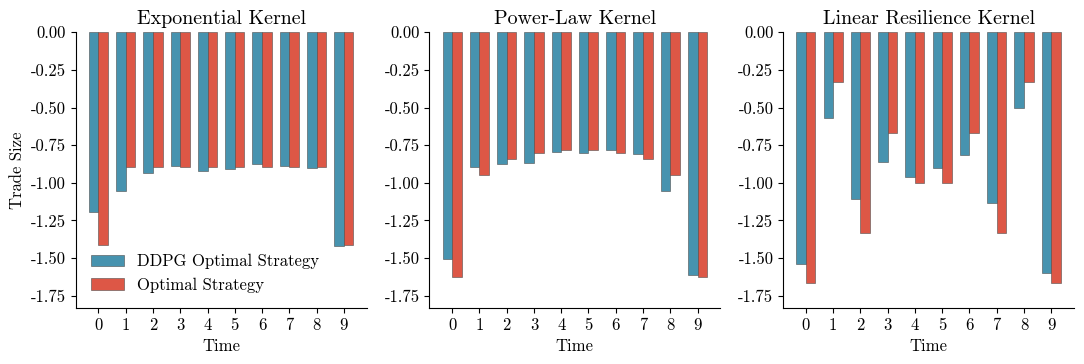

In [50]:
font = {
    "family": "serif",
    "size": 12,
    "serif": "cmr10"
}
matplotlib.rc("font", **font)
plt.rcParams["axes.unicode_minus"] = False

color_optimal = "#DD5746"
color_ddpg = "#4793AF"

def to_numpy_1d(x):
    if hasattr(x, "detach"):
        x = x.detach().cpu().numpy()
    else:
        x = np.asarray(x)
    return np.ravel(x)

def extract_best_vs_optimal(exp):
    """
    Extract:
    - RL strategy from exp.best_strategy[-1]['best_actions']
    - Optimal strategy from exp.optimal_actions
    """
    if not hasattr(exp, "best_strategy") or len(exp.best_strategy) == 0:
        raise ValueError("exp.best_strategy is empty or missing.")

    last_best = exp.best_strategy[-1]

    if not isinstance(last_best, dict):
        raise ValueError("exp.best_strategy[-1] is not a dictionary as expected.")

    if "best_actions" not in last_best:
        raise ValueError("'best_actions' key not found in exp.best_strategy[-1].")

    rl_strat = to_numpy_1d(last_best["best_actions"])
    opt_strat = to_numpy_1d(exp.optimal_actions)

    if len(rl_strat) != len(opt_strat):
        raise ValueError(
            f"Length mismatch: RL={len(rl_strat)} vs OPT={len(opt_strat)}"
        )

    return rl_strat, opt_strat

rl_ex, opt_ex = extract_best_vs_optimal(exp_ex)
rl_pl, opt_pl = extract_best_vs_optimal(exp_pl)
rl_lr, opt_lr = extract_best_vs_optimal(exp_lr)

titles = [
    "Exponential Kernel",
    "Power-Law Kernel",
    "Linear Resilience Kernel"
]

data = [
    (rl_ex, opt_ex),
    (rl_pl, opt_pl),
    (rl_lr, opt_lr),
]

fig, axs = plt.subplots(1, 3, figsize=(11, 3.8))
width = 0.35

global_min = min(
    rl_ex.min(), opt_ex.min(),
    rl_pl.min(), opt_pl.min(),
    rl_lr.min(), opt_lr.min(),
)
global_max = max(
    rl_ex.max(), opt_ex.max(),
    rl_pl.max(), opt_pl.max(),
    rl_lr.max(), opt_lr.max(),
)

for ax, (rl, opt), title in zip(axs, data, titles):
    x = np.arange(len(opt))

    ax.bar(
        x - width / 2,
        rl,
        width,
        color=color_ddpg,
        edgecolor="#4d4d4d",
        linewidth=0.4,
        label="DDPG Optimal Strategy"
    )
    ax.bar(
        x + width / 2,
        opt,
        width,
        color=color_optimal,
        edgecolor="#4d4d4d",
        linewidth=0.4,
        label="Optimal Strategy"
    )

    ax.set_title(title)
    ax.set_xlabel("Time")
    ax.set_xticks(x)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.set_ylim(global_min * 1.1, max(0.0, global_max * 1.1))

axs[0].set_ylabel("Trade Size")
axs[0].legend(frameon=False)

fig.tight_layout()
plt.show()